In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1pkLk2s89-Etn7zIuYV88L_FvDH3sI8qx')
df.head()

,Unnamed: 0,source,name,description,neighborhood_overview,host_name,host_since,host_location,host_about,host_response_time,...,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Precio Venta
0,0,city scrape,Nice room with superb city view,Our cool and comfortable one bedroom apartment...,It is very center of Bangkok and easy access t...,Nuttee,08/05/2010,"Bangkok, Thailand","Hi All, I am nuttee patranavik from Bangkok, T...",within an hour,...,0.0,4.86,4.95,4.82,4.97,4.91,4.66,4.75,0.43,4.95
1,1,previous scrape,"Easy going landlord,easy place",Our cool and comfortable one bedroom apartment...,It is very center of Bangkok and easy access t...,Emy,08/05/2010,"Bangkok, Thailand","Hi All, I am nuttee patranavik from Bangkok, T...",within an hour,...,0.0,4.70,4.70,4.70,4.80,4.80,4.60,4.70,1.00,4.70
2,2,previous scrape,modern-style apartment in Bangkok,A modern-style apartment situated in a cool ne...,Ramkumheang neigbourhood - hip place with food...,Familyroom,12/05/2010,"Bangkok, Thailand",Welcome to Familyroom Apartment.\r\n\r\nA Chic...,within an hour,...,0.0,4.70,4.70,4.70,4.80,4.80,4.60,4.70,1.00,4.70
3,3,city scrape,Spacious one bedroom at The Kris Condo Bldg. 3,Cozy and clean apartment at MRT Sutthisarn sta...,"There is McDonald's, Au bon Pain and Max Value...",Sirilak,27/06/2010,"Bangkok, Thailand",from Bangkok but I'm in and out of the city a ...,within an hour,...,0.0,4.83,5.00,4.67,4.50,4.83,4.83,5.00,0.06,5.00
4,4,city scrape,Condo with Chaopraya River View,at a size of 25sqm for your vacation in BKK.<b...,"There is McDonald's, Au bon Pain and Max Value...",Athitaya,03/09/2010,"Bangkok, Thailand","Full-time legal consultant from Bangkok, Thail...",within an hour,...,0.0,5.00,5.00,5.00,5.00,5.00,5.00,5.00,0.01,5.00


In [54]:
df = df[df['room_type'] == 'Entire home/apt']

In [55]:
df['price'].info()

<class 'pandas.core.series.Series'>
Index: 15885 entries, 0 to 25078
Series name: price
Non-Null Count  Dtype 
--------------  ----- 
15885 non-null  object
dtypes: object(1)
memory usage: 248.2+ KB


In [56]:
df['review_scores_cleanliness'].info()

<class 'pandas.core.series.Series'>
Index: 15885 entries, 0 to 25078
Series name: review_scores_cleanliness
Non-Null Count  Dtype  
--------------  -----  
15885 non-null  float64
dtypes: float64(1)
memory usage: 248.2 KB


In [57]:
df['price'] = df['price'].str.replace('$', '', regex=False)

<ipython-input-57-984255563cfd>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['price'] = df['price'].str.replace('$', '', regex=False)


In [58]:
df['price'] = df['price'].str.replace('.00', '', regex=False)

<ipython-input-58-b1fcc51736e2>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['price'] = df['price'].str.replace('.00', '', regex=False)


In [59]:
df['price'] = df['price'].str.replace(',000', '', regex=False)

In [60]:
df['price'] = df['price'].str.replace(',', '.', regex=False)

In [61]:
df['price'] = df['price'].astype(float)

<ipython-input-62-2a2118cb5fef>:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


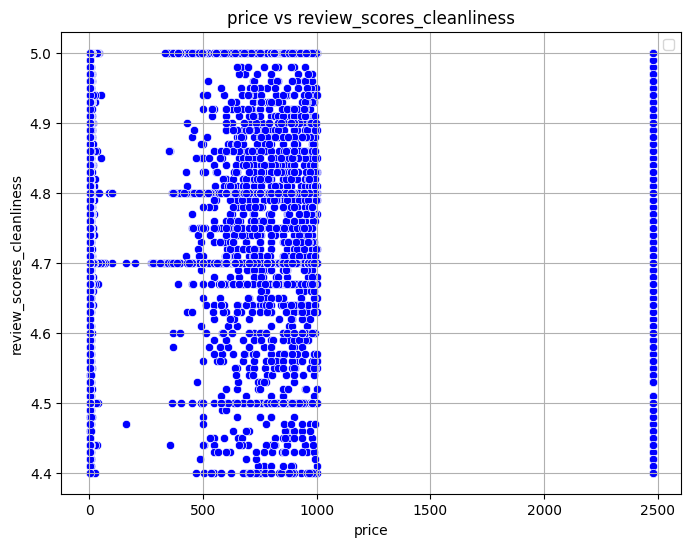

In [62]:
from turtle import color

plt.figure(figsize=(8, 6))
sns.scatterplot(y='review_scores_cleanliness', x='price',  color = 'blue', data=df)
plt.title('price vs review_scores_cleanliness')
plt.xlabel('price')
plt.ylabel('review_scores_cleanliness')
plt.legend()
plt.grid(True)
plt.show()

In [63]:
indep= df[['review_scores_cleanliness']]
dep = df[['price']]

In [64]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [65]:
model.fit(indep, dep)

LinearRegression()

In [66]:
type(model)

sklearn.linear_model._base.LinearRegression

In [67]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['review_scores_cleanliness'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([[-243.74305027]]),
 'rank_': 1,
 'singular_': array([18.4181784]),
 'intercept_': array([1614.49082688])}

In [68]:
m = model.coef_
b = model.intercept_
print('Pendiente:', m)
print('Intercepto:', b)

# Entonce, el modelo lineal sería:
print(f'y = {m[0]}x + {b}')

Pendiente: [[-243.74305027]]
Intercepto: [1614.49082688]
y = [-243.74305027]x + [1614.49082688]


In [ ]:
r2 = model.score(indep, dep)
r2

0.001957902536032341

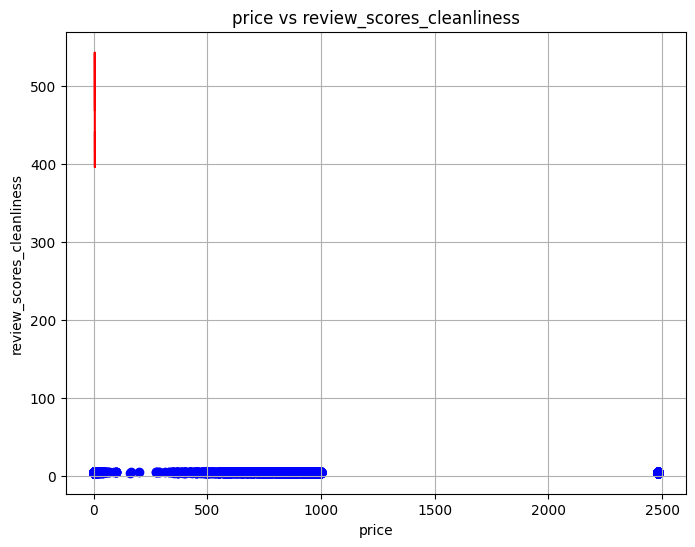

In [70]:
plt.figure(figsize=(8, 6))
plt.scatter(dep, indep, color='blue')
plt.plot(indep, model.predict(indep), color='red')
plt.title('price vs review_scores_cleanliness')
plt.xlabel('price')
plt.ylabel('review_scores_cleanliness')
plt.grid(True)
plt.show()

In [71]:
yPred = model.predict(df[['review_scores_cleanliness']])
yPred

array([[439.64932457],
       [439.64932457],
       [432.33703306],
       ...,
       [468.8984906 ],
       [468.8984906 ],
       [468.8984906 ]])

In [72]:
df['Predicciones'] = yPred
df.head()

,Unnamed: 0,source,name,description,neighborhood_overview,host_name,host_since,host_location,host_about,host_response_time,...,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Precio Venta,Predicciones
0,0,city scrape,Nice room with superb city view,Our cool and comfortable one bedroom apartment...,It is very center of Bangkok and easy access t...,Nuttee,08/05/2010,"Bangkok, Thailand","Hi All, I am nuttee patranavik from Bangkok, T...",within an hour,...,4.86,4.95,4.82,4.97,4.91,4.66,4.75,0.43,4.95,439.649325
8,8,city scrape,"Cozy and spacious 1BR with great view, LT rent","The cozy one bed room apartment, conveniently ...","Charoen krung street, River pier, Iconsiam, Su...",Jean,27/10/2010,"Nonthaburi, Thailand","I love traveling and experience local culture,...",within a few hours,...,4.88,4.71,4.82,4.81,4.69,4.50,4.80,0.11,4.71,439.649325
9,9,city scrape,Central Bangkok 3 Bedroom Apartment,We are Airbnb Super Hosts. Book our apartment ...,Sukhumvit Rd is the shopping and restaurant di...,Henry,30/04/2011,"Bangkok, Thailand",Hello!\r\n\r\nOur collection of privately owne...,a few days or more,...,4.77,4.84,4.85,4.86,4.89,4.86,4.76,0.93,4.84,432.337033
13,13,city scrape,Studio near Chula University/Silom walk to MRT,A centrally located studio apartment with wifi...,It's central yet very local - you'll find easi...,Gael,01/12/2009,"Ko Samui, Thailand","I'm french, living in Samui and Bangkok.\r\n\r...",within a few hours,...,4.80,4.56,4.80,4.90,4.90,4.35,4.80,0.47,4.56,444.524186
14,14,previous scrape,Nice and Cozy Room @ Sathorn Area,A centrally located studio apartment with wifi...,It's central yet very local - you'll find easi...,Wirat,01/07/2011,"Bangkok, Thailand",Nice and Cozy Room @ Sathorn Area. \r\nOne Bed...,within a few hours,...,4.70,4.70,4.70,4.80,4.80,4.60,4.70,1.00,4.70,468.898491


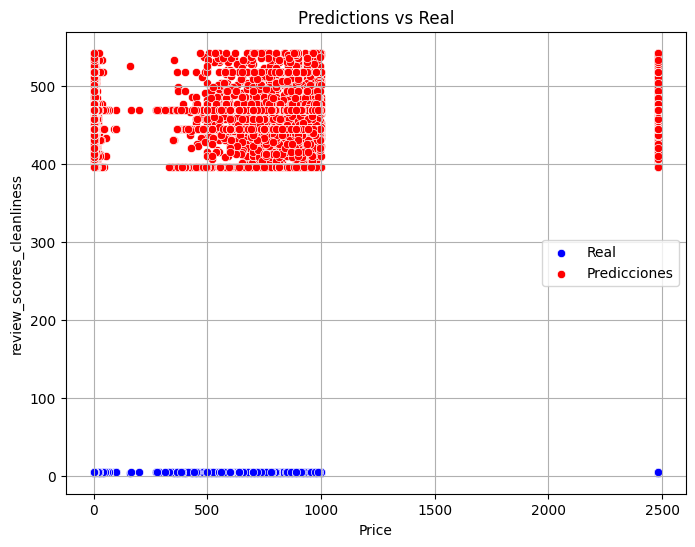

In [73]:
plt.figure(figsize=(8, 6 ))
sns.scatterplot(x='price', y='review_scores_cleanliness', color='blue', data=df, label='Real')
sns.scatterplot(x='price', y='Predicciones', color='red', data=df, label='Predicciones')
#sns.lineplot(x='alcohol', y='Predicciones', color='red', data=df, label='Predicciones')
plt.title('Predictions vs Real')
plt.xlabel('Price')
plt.ylabel('review_scores_cleanliness')
plt.legend()
plt.grid(True)
plt.show()

In [74]:
coefDe = model.score(indep, dep)
coefDe

0.001957902536032341

In [75]:
coefCo = np.sqrt(coefDe)
coefCo

0.04424819246062308

In [76]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('Half-bath', '.5', regex=False)

In [77]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('bath', '', regex=False)

In [78]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('baths', '', regex=False)

In [79]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('s', '', regex=False)

In [80]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('Half-', '.5', regex=False)

In [81]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('shared bath', '', regex=False)

In [82]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('shared','', regex=False)

In [83]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('private bath', '', regex=False)

In [84]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('private', '', regex=False)

In [85]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('Shared half-', '.5', regex=False)

In [86]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('shared baths', '', regex=False)

In [87]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('Private half-', '.5', regex=False)

In [88]:
df['host_is_superhost'] = df['host_is_superhost'].replace({'f': 0, 't': 1}).astype(float)

<ipython-input-88-1126a6e5cd06>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['host_is_superhost'] = df['host_is_superhost'].replace({'f': 0, 't': 1}).astype(float)


In [89]:
df['host_acceptance_rate'] = df['host_acceptance_rate'].str.replace('%', '', regex=False)

In [90]:
df['host_acceptance_rate'] = df['host_acceptance_rate'].astype(float)

In [91]:
df['host_response_rate'] = df['host_response_rate'].str.replace('%', '', regex=False)

In [92]:
df['host_response_rate'] = df['host_response_rate'].astype(float)

In [93]:
df['has_availability'] = df['has_availability'].replace({'f': 0, 't': 1}).astype(float)

<ipython-input-93-a5f192c334b4>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['has_availability'] = df['has_availability'].replace({'f': 0, 't': 1}).astype(float)


In [94]:
df['instant_bookable'] = df['instant_bookable'].replace({'f': 0, 't': 1}).astype(float)

<ipython-input-94-33deb354eca7>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['instant_bookable'] = df['instant_bookable'].replace({'f': 0, 't': 1}).astype(float)


In [95]:
df['host_identity_verified'] = df['host_identity_verified'].replace({'t': 1, 'f': 0}).astype(int)

<ipython-input-95-1e4414937aad>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['host_identity_verified'] = df['host_identity_verified'].replace({'t': 1, 'f': 0}).astype(int)


In [96]:
df = df[['host_acceptance_rate','host_is_superhost','price','accommodates','bathrooms_text','review_scores_cleanliness','host_identity_verified','instant_bookable','host_total_listings_count','bedrooms','review_scores_value','reviews_per_month']]
df

,host_acceptance_rate,host_is_superhost,price,accommodates,bathrooms_text,review_scores_cleanliness,host_identity_verified,instant_bookable,host_total_listings_count,bedrooms,review_scores_value,reviews_per_month
0,92.0,0.0,1.793,2.0,1.5,4.82,1,0.0,2.0,1.0,4.75,0.43
8,80.0,0.0,1.369,2.0,1,4.82,1,0.0,4.0,1.0,4.80,0.11
9,0.0,0.0,5.347,5.0,3.5,4.85,1,0.0,9.0,1.0,4.76,0.93
13,90.0,0.0,1.090,2.0,1,4.80,1,0.0,11.0,1.0,4.80,0.47
14,90.0,0.0,2480.000,2.0,1,4.70,0,0.0,1.0,1.0,4.70,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...
25074,67.0,0.0,1.700,2.0,1,4.70,1,0.0,20.2,1.0,4.70,1.00
25075,67.0,0.0,1.700,2.0,1,4.70,1,0.0,20.2,1.0,4.70,1.00
25076,50.0,0.0,2.500,4.0,2,4.70,1,0.0,94.0,1.0,4.70,1.00
25077,50.0,0.0,1.700,2.0,1,4.70,1,0.0,94.0,1.0,4.70,1.00


In [97]:
correlacion = df.corr()
correlacion

,host_acceptance_rate,host_is_superhost,price,accommodates,bathrooms_text,review_scores_cleanliness,host_identity_verified,instant_bookable,host_total_listings_count,bedrooms,review_scores_value,reviews_per_month
host_acceptance_rate,1.000000,0.204434,0.019315,0.049610,0.040749,0.100425,-0.004928,0.382086,-0.008974,-0.003485,0.087615,0.005643
host_is_superhost,0.204434,1.000000,-0.126904,0.015818,0.005570,0.228108,0.150701,-0.007772,-0.041745,-0.054156,0.203646,0.015506
price,0.019315,-0.126904,1.000000,-0.110823,-0.081885,-0.044248,-0.483656,-0.086470,-0.152816,0.202318,-0.037275,-0.087042
accommodates,0.049610,0.015818,-0.110823,1.000000,0.315790,-0.021846,0.001804,0.035783,-0.065243,-0.040468,-0.012477,0.059538
bathrooms_text,0.040749,0.005570,-0.081885,0.315790,1.000000,0.001588,-0.003445,0.020340,-0.089223,-0.031989,0.007810,0.024879
review_scores_cleanliness,0.100425,0.228108,-0.044248,-0.021846,0.001588,1.000000,0.062295,0.000948,-0.075326,-0.007970,0.597797,-0.251664
host_identity_verified,-0.004928,0.150701,-0.483656,0.001804,-0.003445,0.062295,1.000000,0.172384,0.180578,-0.223843,0.065536,-0.012113
instant_bookable,0.382086,-0.007772,-0.086470,0.035783,0.020340,0.000948,0.172384,1.000000,0.193278,-0.061250,0.000505,0.041385
host_total_listings_count,-0.008974,-0.041745,-0.152816,-0.065243,-0.089223,-0.075326,0.180578,0.193278,1.000000,-0.070083,-0.076937,0.055889
bedrooms,-0.003485,-0.054156,0.202318,-0.040468,-0.031989,-0.007970,-0.223843,-0.061250,-0.070083,1.000000,-0.008882,-0.020249


In [98]:
corr = abs(correlacion)
corr

,host_acceptance_rate,host_is_superhost,price,accommodates,bathrooms_text,review_scores_cleanliness,host_identity_verified,instant_bookable,host_total_listings_count,bedrooms,review_scores_value,reviews_per_month
host_acceptance_rate,1.000000,0.204434,0.019315,0.049610,0.040749,0.100425,0.004928,0.382086,0.008974,0.003485,0.087615,0.005643
host_is_superhost,0.204434,1.000000,0.126904,0.015818,0.005570,0.228108,0.150701,0.007772,0.041745,0.054156,0.203646,0.015506
price,0.019315,0.126904,1.000000,0.110823,0.081885,0.044248,0.483656,0.086470,0.152816,0.202318,0.037275,0.087042
accommodates,0.049610,0.015818,0.110823,1.000000,0.315790,0.021846,0.001804,0.035783,0.065243,0.040468,0.012477,0.059538
bathrooms_text,0.040749,0.005570,0.081885,0.315790,1.000000,0.001588,0.003445,0.020340,0.089223,0.031989,0.007810,0.024879
review_scores_cleanliness,0.100425,0.228108,0.044248,0.021846,0.001588,1.000000,0.062295,0.000948,0.075326,0.007970,0.597797,0.251664
host_identity_verified,0.004928,0.150701,0.483656,0.001804,0.003445,0.062295,1.000000,0.172384,0.180578,0.223843,0.065536,0.012113
instant_bookable,0.382086,0.007772,0.086470,0.035783,0.020340,0.000948,0.172384,1.000000,0.193278,0.061250,0.000505,0.041385
host_total_listings_count,0.008974,0.041745,0.152816,0.065243,0.089223,0.075326,0.180578,0.193278,1.000000,0.070083,0.076937,0.055889
bedrooms,0.003485,0.054156,0.202318,0.040468,0.031989,0.007970,0.223843,0.061250,0.070083,1.000000,0.008882,0.020249


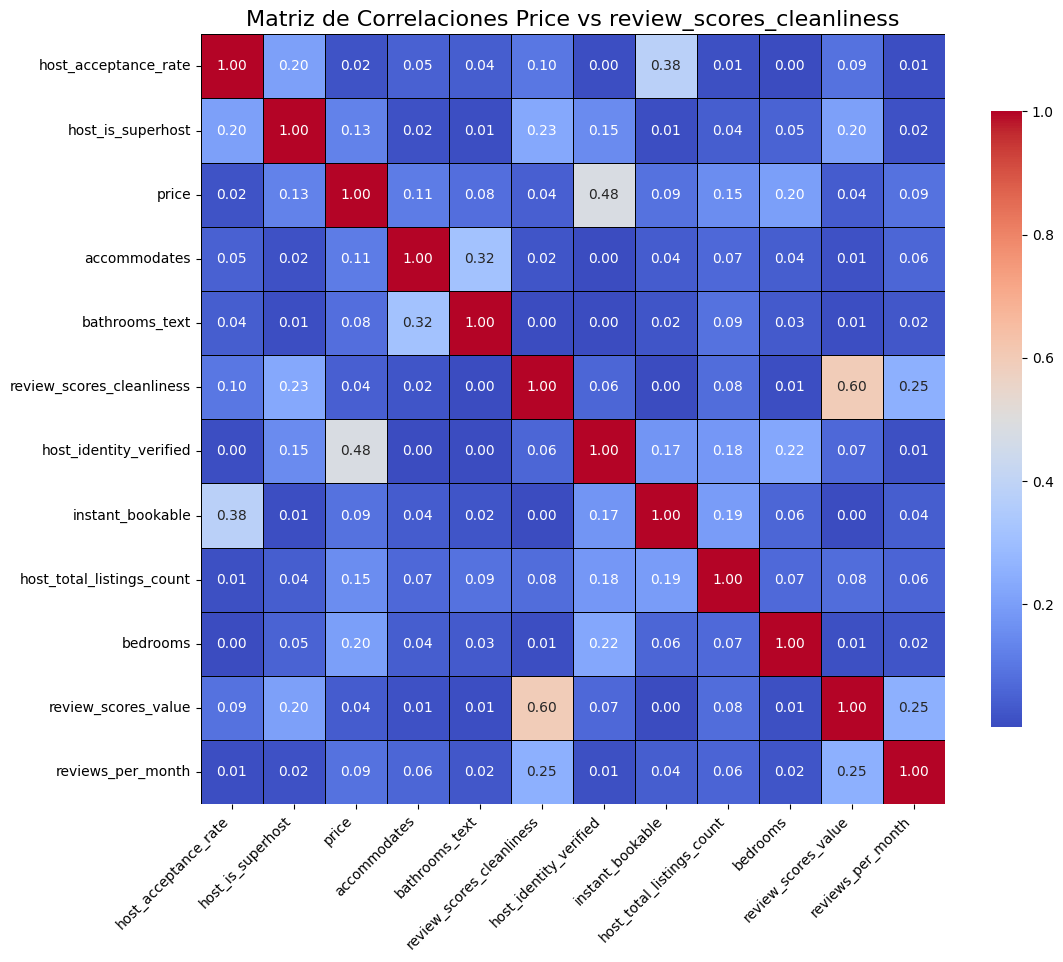

In [99]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, linecolor='black', cbar_kws={'shrink': 0.8}, annot_kws={"size": 10})
plt.title('Matriz de Correlaciones Price vs review_scores_cleanliness', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.show()